# Fig 2

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.io
import os

In [2]:
final_results_dir = '/home/nuttidalab/Documents/spikeRNN/notebooks/CoSyne/figs_final/'

## 2D. Effects of I→I lesioning on high gamma power in inhibitory neurons

In [3]:
normalize_ipscs = 1 # usually will be 1
lesion_connections_list = [0, 'ii'] # if not lesioning put 0, else 'ii' etc
longer_delay = '' # '' if standard delay (150), longer can be 200 or 250

models_type = 'good_models'
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections_list[0] == 0 else f'_lesion{lesion_connections_list[0]}'] #temporary
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

In [4]:
# load a model to get trial times

models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
n_models = len(model_list)
print(f'Total: {n_models} {models_type} models')

for n_model, model_fname in enumerate(model_list):
    
    print(f'Loading model {n_model+1}/{n_models}...')
    model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
    
    break

Total: 41 good_models models
Loading model 1/41...


In [5]:
# get necessary trial timing info 

ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
T = ipsc_data['T'][0][0]
stim_on = ipsc_data['stim_on'][0][0]
stim_dur = ipsc_data['stim_dur'][0][0]
delay = ipsc_data['delay'][0][0]
fs_rate = 200
fs_spk = 20000
del ipsc_data

# get trial times in real time (seconds)
stim_on_time = stim_on/fs_rate
stim_dur_time = stim_dur/fs_rate
delay_time = delay/fs_rate
stim1_on = stim_on_time
stim1_off = stim_on_time + stim_dur_time
stim2_on = stim_on_time + stim_dur_time + delay_time
stim2_off = stim_on_time + 2*stim_dur_time + delay_time

# load spectral time data
t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

# plotting info
stim1_on_idx = np.where(t <= stim1_on)[0][-1]
stim1_off_idx = np.where(t <= stim1_off)[0][-1]
stim2_on_idx = np.where(t <= stim2_on)[0][-1]
stim2_off_idx = np.where(t <= stim2_off)[0][-1]

half_stim1_idx = int((stim1_off_idx - stim1_on_idx)/2) + stim1_on_idx
half_stim2_idx = int((stim2_off_idx - stim2_on_idx)/2) + stim2_on_idx

In [6]:
# adjust for x-axis labels
t_skip = 20

In [7]:
# add utils folder to path, and import bootstrap
import sys
sys.path.append('/home/nuttidalab/Documents/spikeRNN/utils/')
from bootstrap_method import *

/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/
loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers.npz
/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/
loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers_lesionii.npz


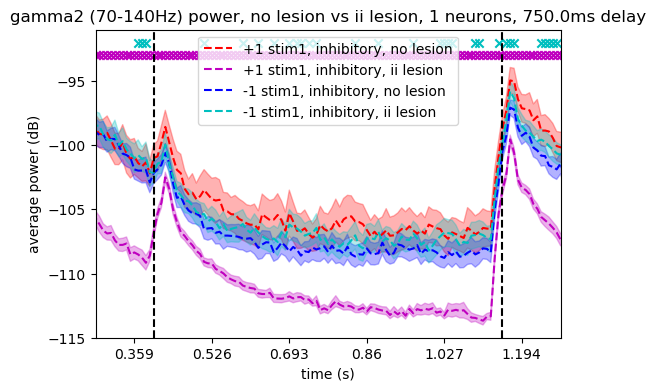

In [8]:
# plot just gamma2 for inhibitory
freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

# plot lesioning differences for each power band
lesion_connections_list = [0, 'ii'] # if not lesioning put 0, else 'ii' etc

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
for lesion_connections in lesion_connections_list:

    lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']

    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    print(results_dir)
    print(f'loading {results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            for k, trial_type in enumerate(['+1', '-1']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)

# save models_bandmeans and models_bandsems in same pickle
import pickle as pk
with open(f'{results_dir}data_2d{norm_name[0]}{delay_name}.pk', 'wb') as f:
    pk.dump([models_bandmeans, models_bandsems, models_all_powers], f)
    

# plot no lesion and ii lesion on the same plot
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            continue
            power_range = [4,8]
        elif power == "alpha":
            continue
            power_range = [9,12]
        elif power == "beta":
            continue
            power_range = [13,30]
        elif power == "gamma1":
            continue
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    plt.figure(figsize=(6,4))
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        if neuron_type == 'excitatory':
            continue
        for k, trial_type in enumerate(['+1', '-1']):
            for m, lesion_connections in enumerate(lesion_connections_list):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                lesion_connections_list[m] = ['no' if lesion_connections == 0 else lesion_connections][0]
                plt.plot(band_mean, label=f'{trial_type} stim1, {neuron_type}, {lesion_connections_list[m]} lesion', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                plt.fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[0][k][j][:,i,:], # different model (lesioning), same trial type, both neuron types
                                                        models_all_powers[1][k][j][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            significant_timepoints = time_vector[pdiff < 0.05]
            plt.scatter(significant_timepoints, np.zeros_like(significant_timepoints)-93+k*1, color=colors[m][k], label='_nolegend_', marker='x')
            
        plt.axvline(x=stim1_on_idx, color='k', linestyle='--')
        plt.axvline(x=stim1_off_idx, color='k', linestyle='--')
        plt.axvline(x=stim2_on_idx, color='k', linestyle='--')
        plt.axvline(x=stim2_off_idx, color='k', linestyle='--')
        plt.xlabel('time (s)')
        plt.ylabel('average power (dB)')
        plt.xticks(range(len(t))[::t_skip],t[::t_skip])
        plt.ylim([-115, -91])
        plt.xlim([half_stim1_idx, half_stim2_idx])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        plt.title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power, no lesion vs {lesion_connections_list[m]} lesion, {j} neurons, {delay/200*1000}ms delay')
        plt.legend()
    # plt.savefig(f'{final_results_dir}2D_{power}_diff_lesioning.svg', format='svg')
